## Initialization

### Dependenceis

In [1]:
from pathlib import Path
import numpy as np
import torch

import visual_autolabel as val
from visual_autolabel.image import (
    UNet as HybridUNet,
    HCPHybridDataset)

## Configuration/Paths

In [2]:
dataset2D_cache_path = '/data/visual-autolabel/datasets/HCP'
dataset3D_cache_path = '/data/visual-autolabel/volumetric/data'
noddi_data_path = '/data/visual-autolabel/volumetric/NODDI'
tx3Dto2D_cache_path = '/data/visual-autolabel/volumetric/data/tx3Dto2D'

val.image.dataset3D_cache_path = dataset3D_cache_path
val.image.noddi_data_path = noddi_data_path

In [33]:
from glob import glob

lowres = True  # Set to False if using full resolution images.
model_dir = Path("/data/visual-autolabel/models")

if lowres:
    restag = 'lowres'
else:
    restag = 'fullres'

# Best result without NODDI data (T1-weighted data only):
model_filepatt_t1w = model_dir / f"hybrid_{restag}*.pt"
model_files_t1w = glob(str(model_filepatt_t1w))
tmp = [
    (float(filename.split('_')[-1][4:-3]), filename)
    for filename in model_files_t1w
    if '_loss' in filename]
model_file_t1w = sorted(tmp)[0][1]

# Best result with NODDI data
model_filepatt_noddi = model_dir / f"hybridnoddi_{restag}*.pt"
model_files_noddi = glob(str(model_filepatt_noddi))
tmp = [
    (float(filename.split('_')[-1][4:-3]), filename)
    for filename in model_files_noddi
    if '_loss' in filename]
model_file_noddi = sorted(tmp)[0][1]

## Initialize Model

In [34]:
# Which model are we using? T1w-model or NODDI-model?
#cnn_inputs = 'T1w'
cnn_inputs = 'NODDI'

if cnn_inputs == 'T1w':
    inputs3D = ('graymask', 'T1', 'T2')
    model_file = model_file_t1w
else:
    inputs3D = ('graymask', 'FA', 'ODI', 'FICVF')
    model_file = model_file_noddi

inputs2D = ('curvature', 'convexity', 'thickness')
outputs = ('V1', 'V2', 'V3')

In [35]:
model = HybridUNet(len(inputs3D), len(inputs3D), len(inputs2D), len(outputs))

ckpt = torch.load(
    model_file,
    weights_only=True)
model.load_state_dict(ckpt)

<All keys matched successfully>

## Initialize Dataset

In [27]:
val_sids = [765864, 209228, 134829, 585256, 901442, 169444, 380036, 389357,
            581450, 198653, 115017, 782561, 176542, 246133, 185442, 601127,
            204521, 195041, 182739, 212419, 263436, 320826, 825048, 192641,
            360030, 177140, 146735, 126426, 789373, 871762, 172130, 171633]

## Evaluate Predictions

In [36]:
def pred_to_surf(pred, k, ds, labelsets=slice(0,3) , view=...):
    (target, k) = ds.dataset2D._to_target_index(k)
    mcache = ds.dataset2D.image_cache
    if view is Ellipsis:
        if imcache.views is None:
            return imcache.invlabels(target, pred, labelsets=labelsets)
        ps = [
            imcache.invlabels(target, pred, view=v, labelsets=labelsets)
            for (v,rect) in imcache.views]
        return tuple(ps)
    return imcache.invlabels(target, pred, view=view, labelsets=labelsets)

In [ ]:
import neuropythy as ny

def simpledice(a, b, k=1):
    a = (a == k)
    b = (b == k)
    return 2 * np.sum(a & b) / (np.sum(a) + np.sum(b))

results = {}
dice = []
for subno in range(len(val_sids)):
    # We recreate the dataset each iteration to prevent the caching from 
    # filling up memory.
    ds = HCPHybridDataset(
        sids=val_sids,
        inputs2D=inputs2D,              
        inputs3D=inputs3D,             
        outputs=outputs,                
        cache_path_2D=dataset2D_cache_path,
        cache_path_3D=dataset3D_cache_path,
        transform_cache_path=tx3Dto2D_cache_path)
    imcache = ds.dataset2D.image_cache
    print(subno)
    k = subno
    target = ds.dataset2D.targets[k]
    
    data3D, sparse_tx, data2D, label = ds[subno]

    if data3D.dim()==4: 
        data3D = data3D.unsqueeze(0)
    if data2D.dim()==3: 
        data2D = data2D.unsqueeze(0)

    tx_list = [sparse_tx] 

    device = next(model.parameters()).device
    data3D  = data3D.to(device, dtype=torch.float32)
    data2D  = data2D.to(device, dtype=torch.float32)
    tx_list = [t.to(device) for t in tx_list]

    with torch.no_grad():
        pred = model(data3D, data2D, tx_list)
        pred = torch.sigmoid(pred)
        fmap_preds = pred_to_surf(pred[0], subno, ds)
        targ = ds.dataset2D.targets[subno]
        (rater, sid) = imcache.unpack_target(target)
        sub = ny.data['hcp_lines'].subjects[sid]
        surf_preds = []
        d = []
        for (ii, fmap_pred) in enumerate(fmap_preds):
            view = imcache.views[ii][0]
            fmap = imcache.get_flatmap(targ, view=view)
            hem = sub.hemis[view['hemisphere']]
            spred = np.zeros(hem.vertex_count, dtype=int)
            spred[fmap.labels] = fmap_pred
            surf_preds.append(spred)
            # Gold labels:
            gold = hem.prop('visual_area')
            d.append([simpledice(spred, gold, k) for k in (1,2,3)])
    dice.append(d)
    results[sid] = tuple(surf_preds)
    # Clear ny cache:
    ny = ny.reload_neuropythy()
    # At this point, we have surf_preds, which is a list of:
    # (lh_labels, rh_labels) where each of the *_labels elements is a 
    # vector with 1 label value per vertex on the entire cortical surface
    # for the subject.
    
    # This needs to be update to use dice loss over surface vertices.
    # This involves comparing lh_labels from surf_preds to the subject's
    # LH 'visual_area' property, e.g. in sub.hemis['lh'].prop('visual_area')
    # SO:
    #  - sub.hemis['lh'].prop('visual_area') are the TRUE labels for the subject's LH
    #  - surf_reds[0] is the PREDICTED labels for the subject's LH
    #  - sub.hemis['rh'].prop('visual_area') are the TRUE labels for the subject's RH
    #  - surf_reds[1] is the PREDICTED labels for the subject's RH

print("pred:", pred.shape)

0


In [15]:
results

{765864: (array([2, 2, 2, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0])),
 209228: (array([1, 1, 1, ..., 0, 0, 0]), array([2, 2, 2, ..., 0, 0, 0])),
 134829: (array([1, 1, 1, ..., 0, 0, 0]), array([2, 2, 2, ..., 0, 0, 0])),
 585256: (array([1, 1, 1, ..., 0, 0, 0]), array([2, 2, 2, ..., 0, 0, 0])),
 901442: (array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0])),
 169444: (array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0])),
 380036: (array([2, 2, 1, ..., 0, 0, 0]), array([2, 2, 2, ..., 0, 0, 0])),
 389357: (array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0])),
 581450: (array([1, 1, 1, ..., 0, 0, 0]), array([2, 2, 2, ..., 0, 0, 0])),
 198653: (array([2, 2, 2, ..., 0, 0, 0]), array([2, 2, 2, ..., 0, 0, 0])),
 115017: (array([1, 1, 2, ..., 0, 0, 0]), array([2, 2, 2, ..., 0, 0, 0])),
 782561: (array([2, 2, 2, ..., 0, 0, 0]), array([2, 2, 2, ..., 0, 0, 0])),
 176542: (array([1, 1, 1, ..., 0, 0, 0]), array([2, 1, 1, ..., 0, 0, 0])),
 246133: (array([1, 1, 1,

In [18]:
dice = np.array(dice)

In [24]:
np.mean(np.concatenate(dice[:,:,0]))

np.float64(0.8235191223756912)

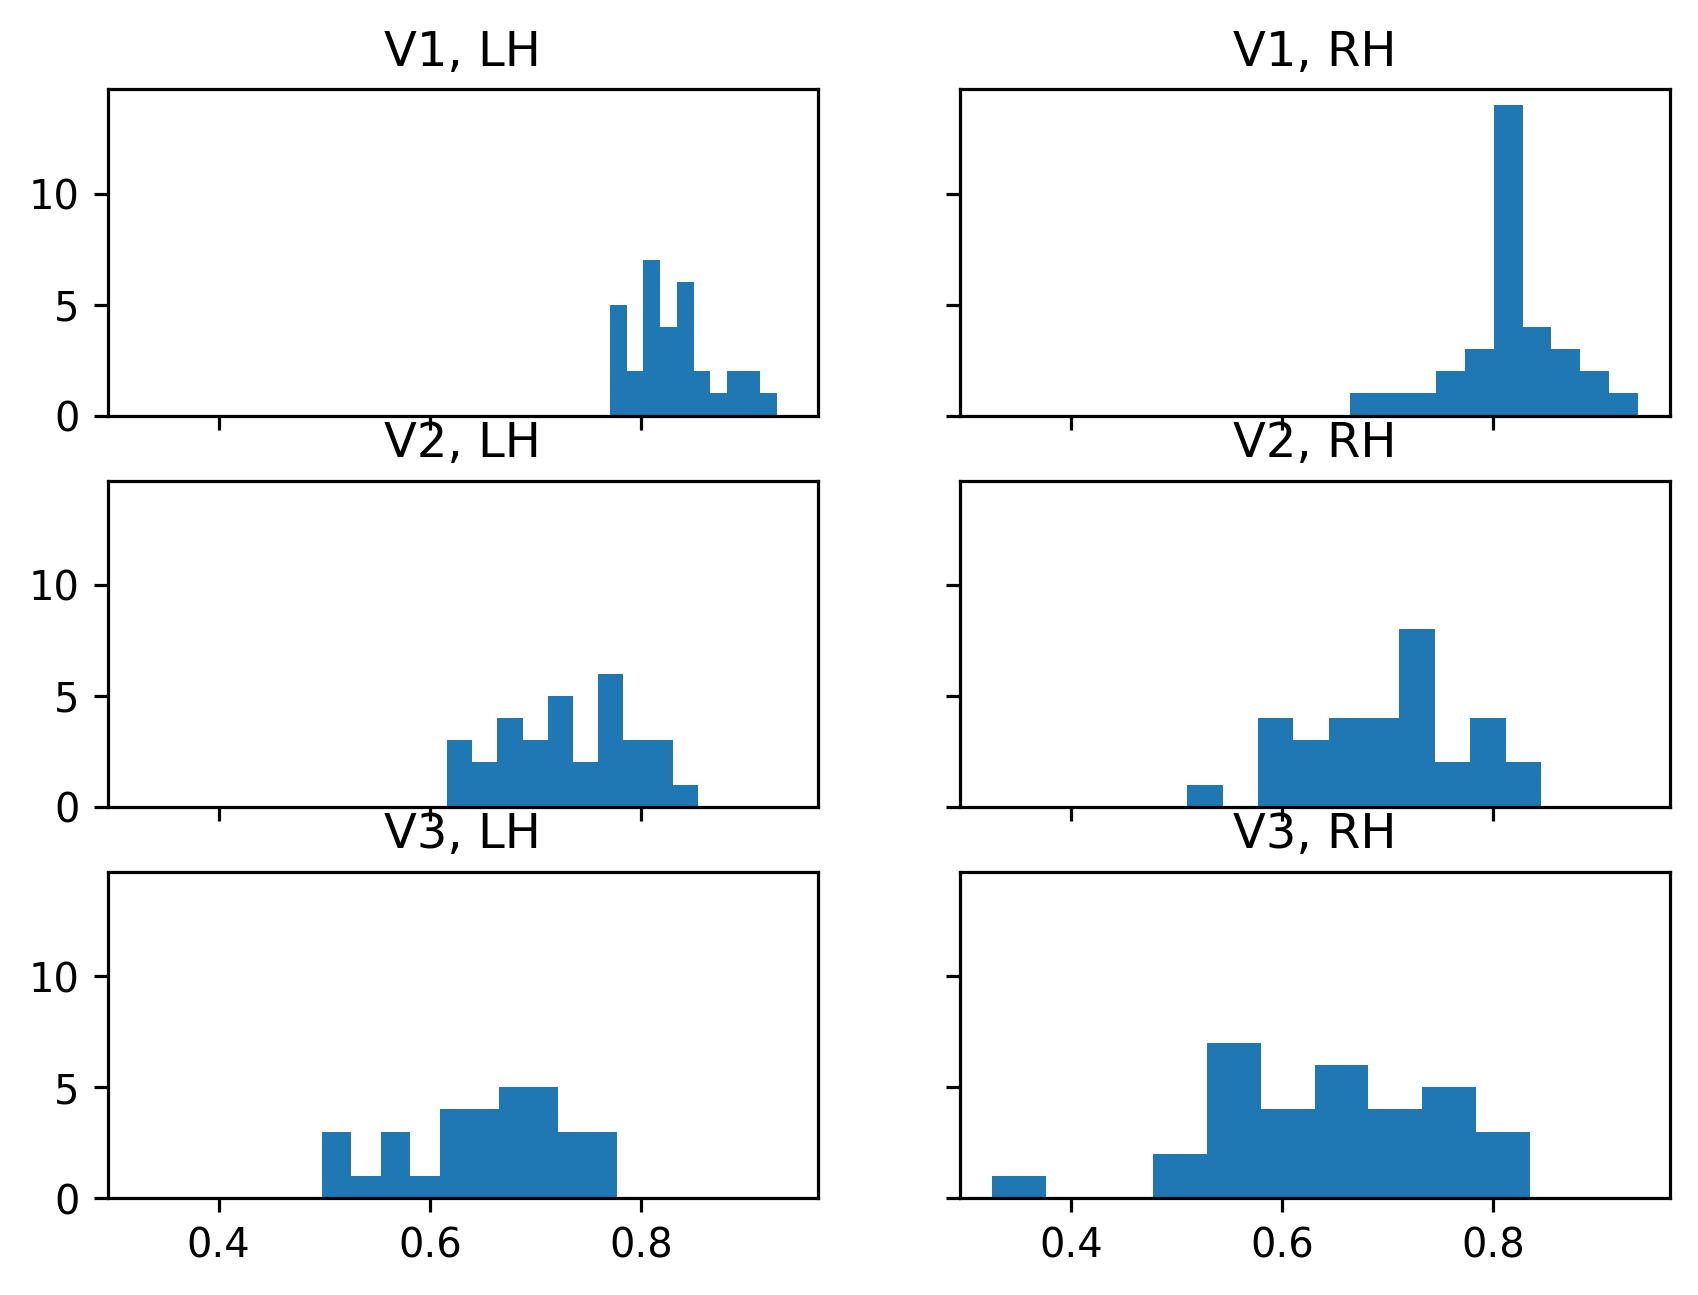

In [26]:
import matplotlib.pyplot as plt

(fig, axs) = plt.subplots(3, 2, figsize=(7,5), dpi=288, sharex=True, sharey=True)

for (h,axcol) in zip([0,1], axs.T):
    for (l,ax) in zip([0,1,2], axcol):
        ax.hist(dice[:, h, l])
        ax.set_title(f"V{l+1}, " + ['LH','RH'][h])

In [27]:
np.mean(dice)

np.float64(0.7291400965469806)

In [20]:
sub = ny.hcp_subject(765864)

ny.cortex_plot(sub.lh, surface='inflated', color=surf_preds[0], mask=(surf_preds[0] > 0))

Figure(box_center=[0.5, 0.5, 0.5], box_size=[1.0, 1.0, 1.0], camera=PerspectiveCamera(fov=0.644570721372708, p…